In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("/content/drive/MyDrive/ultimate_student_productivity_dataset_5000.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 21)


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


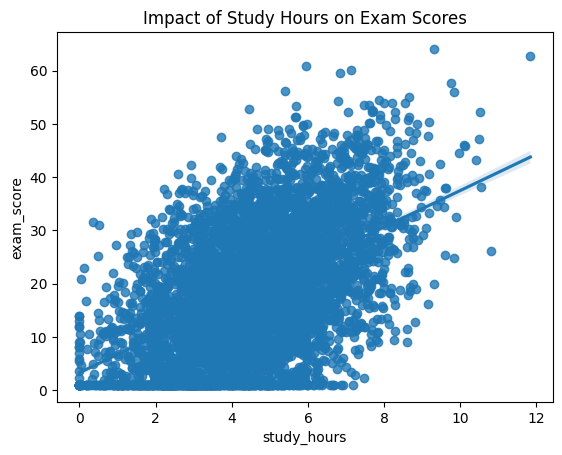

In [4]:
plt.figure()

sns.regplot(
    x="study_hours",
    y="exam_score",
    data=df
)

plt.title("Impact of Study Hours on Exam Scores")
plt.show()


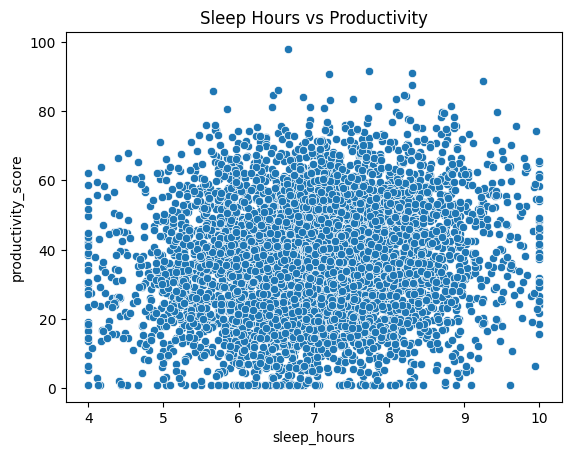

In [5]:
plt.figure()

sns.scatterplot(
    x="sleep_hours",
    y="productivity_score",
    data=df
)

plt.title("Sleep Hours vs Productivity")
plt.show()

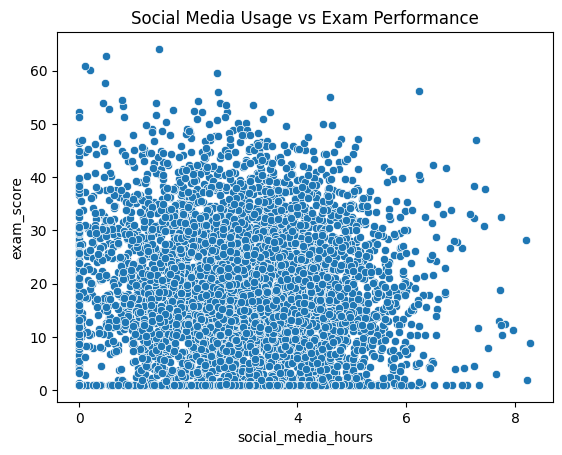

In [6]:
plt.figure()

sns.scatterplot(
    x="social_media_hours",
    y="exam_score",
    data=df
)

plt.title("Social Media Usage vs Exam Performance")
plt.show()

In [7]:
corr, p_value = stats.pearsonr(df["study_hours"], df["exam_score"])

print("Correlation:", corr)
print("P-value:", p_value)


Correlation: 0.5134337022211001
P-value: 0.0


In [8]:
corr2, p_value2 = stats.pearsonr(
    df["sleep_hours"],
    df["productivity_score"]
)

print("Correlation:", corr2)
print("P-value:", p_value2)

Correlation: 0.14966592095210507
P-value: 1.9347788844941305e-26


In [9]:
high_study = df[df["study_hours"] > 4]["exam_score"]
low_study = df[df["study_hours"] <= 4]["exam_score"]

t_stat, p_val = stats.ttest_ind(high_study, low_study)

print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 30.067932283178315
P-value: 1.021992098617213e-182


In [10]:
mean_exam = df["exam_score"].mean()
std_exam = df["exam_score"].std()
n = len(df)

ci = stats.norm.interval(
    0.95,
    loc=mean_exam,
    scale=std_exam/np.sqrt(n)
)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (np.float64(18.467508457035688), np.float64(19.139995542964318))


In [11]:
productivity_level = df.groupby("academic_level")["productivity_score"].mean()

print(productivity_level)

academic_level
High School      37.246453
Postgraduate     37.231227
Undergraduate    37.326892
Name: productivity_score, dtype: float64


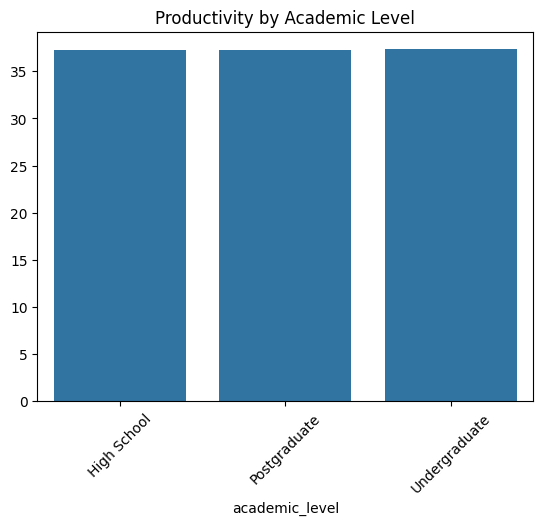

In [12]:
plt.figure()

sns.barplot(
    x=productivity_level.index,
    y=productivity_level.values
)

plt.xticks(rotation=45)

plt.title("Productivity by Academic Level")
plt.show()

In [13]:
import statsmodels.api as sm

X = df[["study_hours","sleep_hours","social_media_hours"]]
X = sm.add_constant(X)

y = df["exam_score"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     846.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:18:18   Log-Likelihood:                -18545.
No. Observations:                5000   AIC:                         3.710e+04
Df Residuals:                    4996   BIC:                         3.712e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -12.5412      0

In [15]:
from scipy.stats import f_oneway

groups = []

for level in df["academic_level"].unique():
    groups.append(df[df["academic_level"] == level]["exam_score"])

anova_stat, anova_p = f_oneway(*groups)

print("ANOVA F-Statistic:", anova_stat)
print("P-value:", anova_p)

ANOVA F-Statistic: 0.25774930279875174
P-value: 0.7727992173764863


In [16]:
from scipy.stats import zscore

df["z_score"] = zscore(df["exam_score"])

outliers = df[df["z_score"].abs() > 3]

print("Outliers count:", len(outliers))
outliers.head()

Outliers count: 8


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,z_score
20,21,23,Male,Undergraduate,9.31,4.04,3.06,1.46,1.23,7.74,...,118,1,0,Good,10,60.72,31.88,91.52,64.09,3.733524
493,494,24,Female,Undergraduate,9.84,1.97,2.20,2.54,0.11,7.42,...,80,0,0,Poor,4,57.10,24.46,76.02,55.96,3.063264
1040,1041,18,Male,Postgraduate,5.41,2.03,2.13,6.23,1.68,9.63,...,222,0,0,Poor,9,38.87,12.85,70.37,56.09,3.073982
1545,1546,22,Female,Undergraduate,6.83,2.41,1.28,2.53,0.40,7.91,...,57,0,0,Average,10,53.69,10.91,73.47,59.59,3.362531
3375,3376,17,Female,High School,11.84,3.31,1.28,0.48,0.11,6.66,...,162,0,0,Poor,10,63.48,32.60,98.02,62.82,3.628821


In [17]:
corr_matrix = df.corr(numeric_only=True)

exam_corr = corr_matrix["exam_score"].sort_values(ascending=False)

print("Feature Importance (Correlation with Exam Score):")
print(exam_corr)

Feature Importance (Correlation with Exam Score):
z_score                 1.000000
exam_score              1.000000
productivity_score      0.886401
focus_index             0.749879
mental_health_score     0.546547
study_hours             0.513434
sleep_hours             0.234710
self_study_hours        0.083602
exercise_minutes        0.040724
online_classes_hours    0.004975
age                    -0.009047
student_id             -0.029406
gaming_hours           -0.054506
caffeine_intake_mg     -0.075586
social_media_hours     -0.106116
screen_time_hours      -0.131940
part_time_job          -0.149807
upcoming_deadline      -0.215342
burnout_level          -0.407808
Name: exam_score, dtype: float64


In [18]:
import statsmodels.api as sm

X = df[["study_hours","sleep_hours","social_media_hours","productivity_score"]]
X = sm.add_constant(X)

y = df["exam_score"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     5021.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:21:29   Log-Likelihood:                -15539.
No. Observations:                5000   AIC:                         3.109e+04
Df Residuals:                    4995   BIC:                         3.112e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -9.6908      0

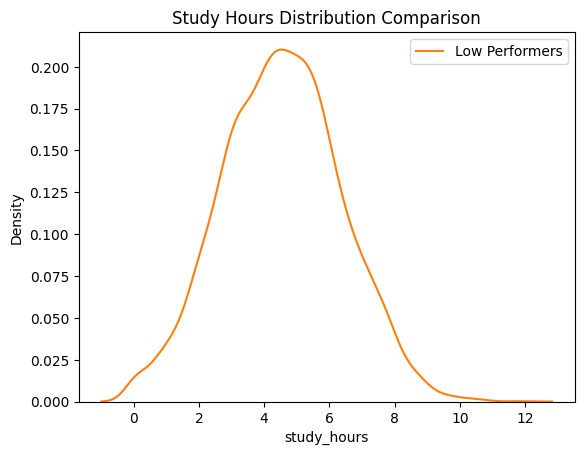

In [20]:
plt.figure()

sns.kdeplot(high_perf["study_hours"], label="High Performers")
sns.kdeplot(low_perf["study_hours"], label="Low Performers")

plt.legend()
plt.title("Study Hours Distribution Comparison")

plt.show()

In [22]:
high_perf = df[df["exam_score"] > 75]
low_perf = df[df["exam_score"] <= 75]

print("High Performers Avg Study:", high_perf["study_hours"].mean())
print("Low Performers Avg Study:", low_perf["study_hours"].mean())

print("High Performers Sleep:", high_perf["sleep_hours"].mean())
print("Low Performers Sleep:", low_perf["sleep_hours"].mean())

High Performers Avg Study: nan
Low Performers Avg Study: 4.539594
High Performers Sleep: nan
Low Performers Sleep: 7.0164919999999995
